<a href="https://colab.research.google.com/github/Josue-Aldebaran-G-L/Reto-2-Modelado-Predictivo/blob/main/Reto_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Configuración Inicial

In [ ]:
# ================================================================
# CONFIGURACION DEL LABORATORIO - NO MODIFICAR
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

print("\u2554\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2557")
print("\u2551     LABORATORIO DE OPTIMIZACI\u00d3N - GRADIENTE DESCENDENTE   \u2551")
print("\u2551                                                           \u2551")
print("\u2551   Misi\u00f3n: Encontrar el Valle Perdido                      \u2551")
print("\u2551   Herramienta: Gradiente Descendente desde Cero           \u2551")
print("\u2551                                                           \u2551")
print("\u255a\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u255d")

╔═══════════════════════════════════════════════════════════╗
║     LABORATORIO DE OPTIMIZACIÓN - GRADIENTE DESCENDENTE   ║
║                                                           ║
║   Misión: Encontrar el Valle Perdido                      ║
║   Herramienta: Gradiente Descendente desde Cero           ║
║                                                           ║
╚═══════════════════════════════════════════════════════════╝


## Las Funciones Objetivo

Trabajarás con dos funciones:

### Función 1D:
$$f(x) = (x - 3)^2 + 5$$
- Derivada: $f'(x) = 2(x - 3)$
- Mínimo en: $x = 3$, $f(3) = 5$

### Función 2D:
$$f(x, y) = x^2 + y^2 - 4x - 2y + 5$$
- Gradiente: $\nabla f = [2x - 4,\; 2y - 2]$
- Mínimo en: $(x, y) = (2, 1)$, $f(2, 1) = 0$

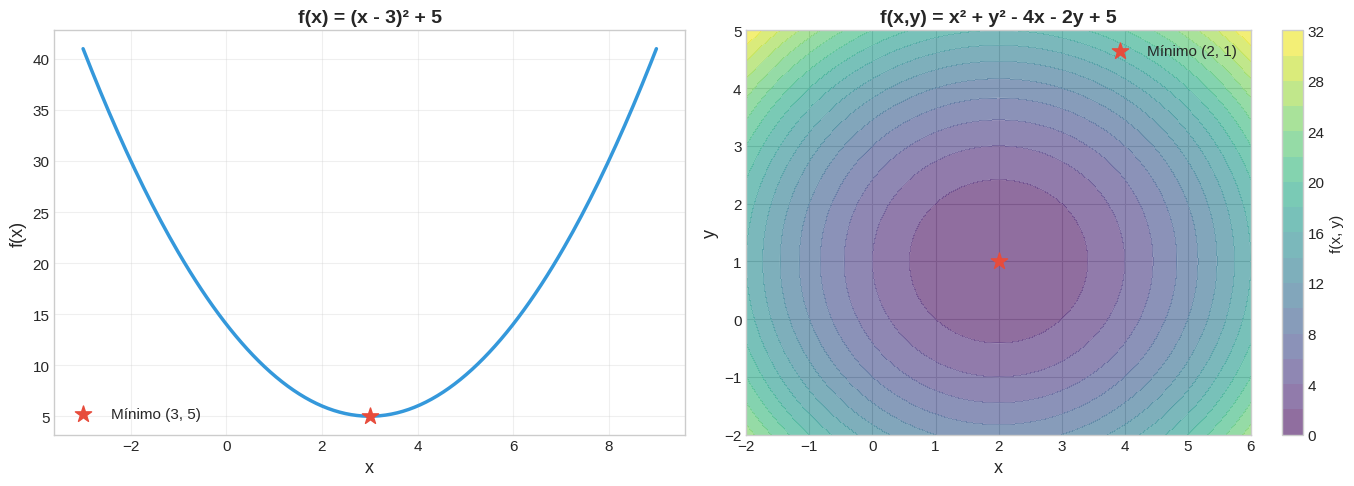

Estas son las dos 'montañas' que deberás descender.
Tu misión: implementar el algoritmo que encuentre el valle (mínimo).


In [ ]:
# ================================================================
# FUNCIONES OBJETIVO - PROPORCIONADAS
# ================================================================

# --- Funcion 1D ---
def f_1d(x):
    """f(x) = (x - 3)^2 + 5"""
    return (x - 3)**2 + 5

def df_1d(x):
    """Derivada de f: f'(x) = 2(x - 3)"""
    return 2 * (x - 3)

# --- Funcion 2D ---
def f_2d(x, y):
    """f(x, y) = x^2 + y^2 - 4x - 2y + 5"""
    return x**2 + y**2 - 4*x - 2*y + 5

def grad_2d(x, y):
    """Gradiente de f: [2x - 4, 2y - 2]"""
    return np.array([2*x - 4, 2*y - 2])

# Visualizacion de las funciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Funcion 1D ---
x = np.linspace(-3, 9, 200)
axes[0].plot(x, f_1d(x), color='#3498db', linewidth=2.5)
axes[0].scatter([3], [5], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (3, 5)')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('f(x) = (x - 3)\u00b2 + 5', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Funcion 2D (contornos) ---
x2 = np.linspace(-2, 6, 200)
y2 = np.linspace(-2, 5, 200)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = f_2d(X2, Y2)

contour = axes[1].contourf(X2, Y2, Z2, levels=20, cmap='viridis', alpha=0.6)
axes[1].contour(X2, Y2, Z2, levels=20, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=axes[1], label='f(x, y)')
axes[1].scatter([2], [1], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (2, 1)')
axes[1].set_xlabel('x', fontsize=13)
axes[1].set_ylabel('y', fontsize=13)
axes[1].set_title('f(x,y) = x\u00b2 + y\u00b2 - 4x - 2y + 5', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Estas son las dos 'monta\u00f1as' que deber\u00e1s descender.")
print("Tu misi\u00f3n: implementar el algoritmo que encuentre el valle (m\u00ednimo).")

# Parte 1: Gradiente Descendente en 1D

## Ejercicio 1.1:

In [ ]:
def gradiente_descendente_1d(x_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para la funcion f(x) = (x - 3)^2 + 5

    Parametros:
    -----------
    x_inicial : float
        Punto de inicio
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si |x_nuevo - x_actual| < tolerancia, se considera convergido

    Retorna:
    --------
    dict con:
        'x_final': float - Valor final de x
        'f_final': float - Valor de f(x_final)
        'iteraciones': int - Numero de iteraciones realizadas
        'convergido': bool - Si el algoritmo convergio
        'historial_x': list - Valores de x en cada iteracion
        'historial_f': list - Valores de f(x) en cada iteracion
    """

    x_actual = x_inicial
    historial_x = [x_inicial]
    historial_f = [f_1d(x_inicial)]
    convergido = False

    for i in range(max_iter):
      derivada = df_1d(x_actual)
      x_nuevo = x_actual - learning_rate * derivada

      historial_x.append(x_nuevo)
      historial_f.append(f_1d(x_nuevo))

      if np.abs(x_nuevo - x_actual) < tolerancia:
        convergido = True
        break

      x_actual = x_nuevo

    return {
        'x_final': x_nuevo,
        'f_final': f_1d(x_nuevo),
        'iteraciones': i + 1,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_f': historial_f
    }

## Ejercicio 1.2:

In [ ]:
resultado = gradiente_descendente_1d(
    x_inicial=-2.0,
    learning_rate=0.1,
    max_iter=100
)

In [ ]:
print("PRUEBA DE GRADIENTE DESCENDENTE 1D")
print("=" * 50)
print(f"Punto inicial:     x = -2.0")
print(f"Learning rate:     0.1")
print(f"\nResultados:")
print(f"  x final:         {resultado['x_final']:.6f}  (esperado: 3.0)")
print(f"  f(x) final:      {resultado['f_final']:.6f}  (esperado: 5.0)")
print(f"  Iteraciones:     {resultado['iteraciones']}")
print(f"  Convergido:      {resultado['convergido']}")

PRUEBA DE GRADIENTE DESCENDENTE 1D
Punto inicial:     x = -2.0
Learning rate:     0.1

Resultados:
  x final:         2.999996  (esperado: 3.0)
  f(x) final:      5.000000  (esperado: 5.0)
  Iteraciones:     63
  Convergido:      True


In [ ]:
error = abs(resultado['x_final'] - 3.0)
if error < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error:.6f})")


  RESULTADO: Correcto (error = 0.000004)


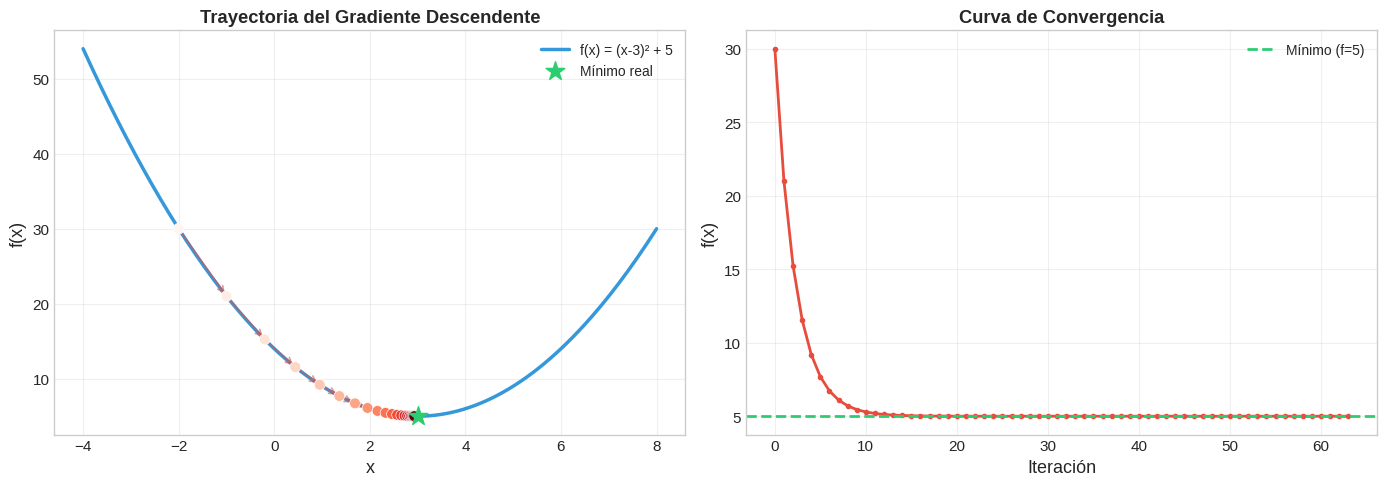

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafica 1: Trayectoria sobre la funcion ---
x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f_1d(x_range), color='#3498db', linewidth=2.5, label='f(x) = (x-3)\u00b2 + 5')

hx = resultado['historial_x']
hf = resultado['historial_f']

n_mostrar = min(20, len(hx))
axes[0].scatter(hx[:n_mostrar], hf[:n_mostrar], c=range(n_mostrar),
                cmap='Reds', s=60, zorder=5, edgecolors='white', linewidth=0.5)
for i in range(min(10, n_mostrar - 1)):
    axes[0].annotate('', xy=(hx[i+1], hf[i+1]), xytext=(hx[i], hf[i]),
                     arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2, alpha=0.6))

axes[0].scatter([3], [5], color='#2ecc71', s=200, marker='*', zorder=6, label='M\u00ednimo real')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectoria del Gradiente Descendente', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Grafica 2: Convergencia ---
axes[1].plot(range(len(hf)), hf, 'o-', color='#e74c3c', linewidth=2, markersize=3)
axes[1].axhline(y=5, color='#2ecc71', linestyle='--', linewidth=2, label='M\u00ednimo (f=5)')
axes[1].set_xlabel('Iteraci\u00f3n', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Curva de Convergencia', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_1d_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()

# Parte 2: Experimentación con Learning Rates

## Ejercicio 2.1:

In [ ]:
# ============================================================
# TU CODIGO AQUI: Ejecuta experimentos con diferentes learning rates
# ============================================================

learning_rates_prueba = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x_inicial_prueba = -2.0
max_iter_prueba = 200

# Almacenar resultados
resultados_lr = []

for lr in learning_rates_prueba:
  resultado = gradiente_descendente_1d(
    x_inicial=x_inicial_prueba,
    learning_rate=lr,
    max_iter=max_iter_prueba
  )

  resultados_lr.append(resultado)

# Mostrar tabla de resultados
print("EXPERIMENTOS CON DIFERENTES LEARNING RATES")
print("=" * 80)
print(f"{'LR':>8} {'x_final':>12} {'f(x)_final':>12} {'Iteraciones':>12} {'Convergi\u00f3':>12}")
print("-" * 60)

for lr, res in zip(learning_rates_prueba, resultados_lr):
    print(f"{lr:>8.3f} {res['x_final']:>12.6f} {res['f_final']:>12.6f} {res['iteraciones']:>12} {str(res['convergido']):>12}")

EXPERIMENTOS CON DIFERENTES LEARNING RATES
      LR      x_final   f(x)_final  Iteraciones    Convergió
------------------------------------------------------------
   0.001    -0.350258    16.224229          200        False
   0.010     2.912060     5.007733          200        False
   0.100     2.999996     5.000000           63         True
   0.500     3.000000     5.000000            2         True
   0.900     3.000000     5.000000           73         True
   1.000    -2.000000    30.000000          200        False
   1.500 -8034690221294951377709810461705813012611014968913964176506880.000000 64556246952172714741397979300075296858242644820730587820766483913516190550421029865741133832003445785897579299318687334400.000000          200        False


## Ejercicio 2.2:

Se decidió eliminar el lr de 1.5 ya que creció demasiado.


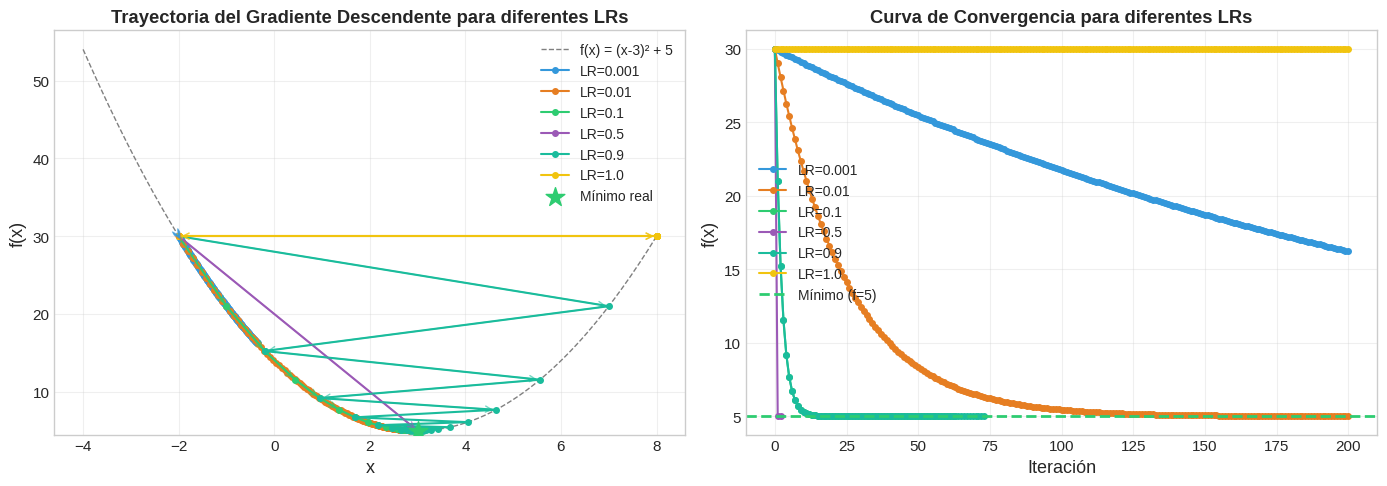

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores = [
    '#3498db',
    '#e67e22',
    '#2ecc71',
    '#9b59b6',
    '#1abc9c',
    '#f1c40f',
    '#e74c3c'
]

x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f_1d(x_range), color='gray', linestyle='--', linewidth=1, label='f(x) = (x-3)² + 5')

for idx, (lr, res) in enumerate(zip(learning_rates_prueba, resultados_lr)):
    if(lr == 1.5):
        continue

    hx = res['historial_x']
    hf = res['historial_f']
    color = colores[idx % len(colores)]

    axes[0].plot(hx, hf, 'o-', markersize=4, color=color, label=f'LR={lr}')
    n_mostrar_trayectoria = min(5, len(hx) - 1)
    for i in range(n_mostrar_trayectoria):
         axes[0].annotate('', xy=(hx[i+1], hf[i+1]), xytext=(hx[i], hf[i]),
                          arrowprops=dict(arrowstyle='->', color=color, lw=1, alpha=0.6))

    axes[1].plot(range(len(hf)), hf, 'o-', markersize=4, color=color, label=f'LR={lr}')


axes[0].scatter([3], [5], color='#2ecc71', s=200, marker='*', zorder=6, label='Mínimo real')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectoria del Gradiente Descendente para diferentes LRs', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(bottom=4.5)

axes[1].axhline(y=5, color='#2ecc71', linestyle='--', linewidth=2, label='Mínimo (f=5)')
axes[1].set_xlabel('Iteración', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Curva de Convergencia para diferentes LRs', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

print("Se decidió eliminar el lr de 1.5 ya que creció demasiado.")
plt.tight_layout()
plt.savefig('gd_1d_comparativa_lr.png', dpi=150, bbox_inches='tight')
plt.show()

El valor máximo de f(x) para LR=1.5 es: 6.46e+121.


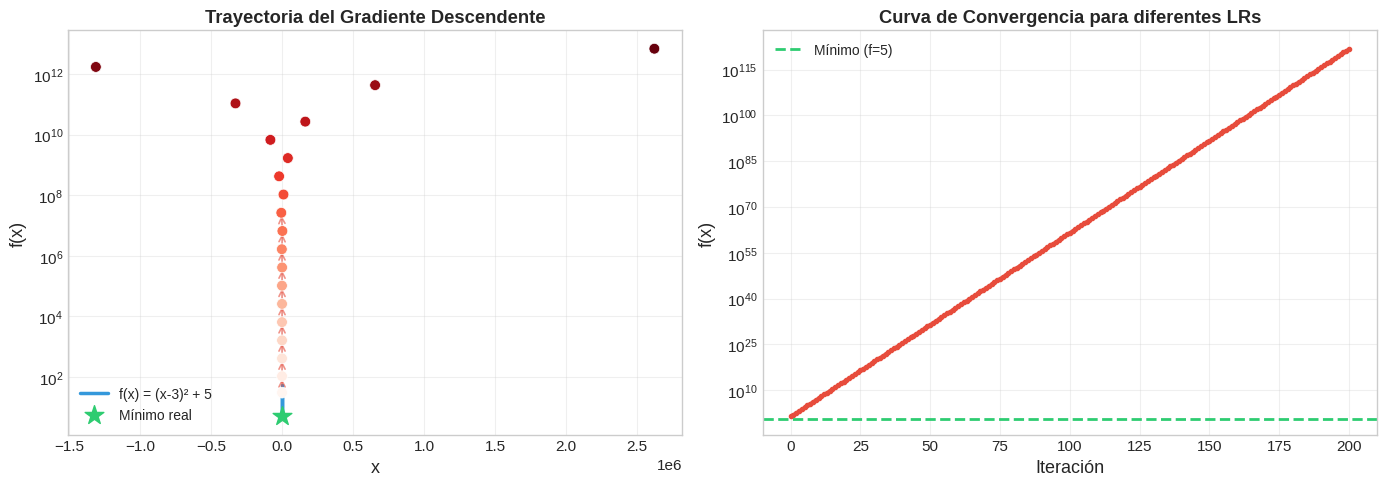

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafica 1: Trayectoria sobre la funcion ---

x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f_1d(x_range), color='#3498db', linewidth=2.5, label='f(x) = (x-3)² + 5')

hx = resultados_lr[6]['historial_x']
hf = resultados_lr[6]['historial_f']

n_mostrar = min(20, len(hx))
axes[0].scatter(hx[:n_mostrar], hf[:n_mostrar], c=range(n_mostrar),
                cmap='Reds', s=60, zorder=5, edgecolors='white', linewidth=0.5)
for i in range(min(10, n_mostrar - 1)):
    axes[0].annotate('', xy=(hx[i+1], hf[i+1]), xytext=(hx[i], hf[i]),
                     arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2, alpha=0.6))

axes[0].scatter([3], [5], color='#2ecc71', s=200, marker='*', zorder=6, label='Mínimo real')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectoria del Gradiente Descendente', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# --- Grafica 2: Convergencia ---

axes[1].plot(range(len(hf)), hf, 'o-', color='#e74c3c', linewidth=2, markersize=3)
axes[1].axhline(y=5, color='#2ecc71', linestyle='--', linewidth=2, label='Mínimo (f=5)')
axes[1].set_xlabel('Iteración', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Curva de Convergencia para diferentes LRs', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

print(f"El valor máximo de f(x) para LR=1.5 es: {max(hf):.2e}.")
plt.tight_layout()
plt.savefig('gd_1d_comparativa_lr.png', dpi=150, bbox_inches='tight')
plt.show()

## **Responde estas preguntas basandote en tus experimentos:**

1. **¿Qué pasa con un learning rate muy pequeño (0.001)?**
   - *El tamaño de paso, al ser tan pequeño, causa que requiera de muchísimos pasos para poder llegar al óptimo, por lo que su convergencia es excesivamente lenta.*

2. **¿Cúal consideras el mejor learning rate y por qué?**
   - *El learning rate de 0.5, ya que solo le tomó 2 iteraciones, en comparación con los otros que requirieron hasta más de 50 iteraciones.*

3. **¿Qué pasa con learning rates >= 1.0?**
   - *En el esenario con learning rate de 1 entró en un bucle, mientras que el de learning rate de 1.5 no convergió, esto debe ya que en $x=-2$: $$\frac{df(-2)}{dx}=2(-2-3)=-10$$ Si consideramos que $α≥1$, entonces: $$α≥1→10α≥10→-2+10α≥8$$ $$x_1=x_0-(\frac{df(-2)}{dx}*α)=-2-(-10α)=-2+10α$$ $$x_1≥8$$ Se sabe que: $$f(x_0)=f(-2)=(-2-3)^2+5=30$$ Y tambien se sabe que la función su segunda derivada está dada por: $$\frac{d^2f(x)}{dx^2}=2$$ Como: $$∀x∈ℝ [\frac{d^2f(x)}{dx^2}>0] $$ Entonces los intervalos de concavidad hacia arriba está definida por todo el conjunto ℝ y debido a la natureleza de toda función parabolica, entonces a partir del mínimo ubicado en $x=3$, tenemos que: $$∀b≥a≥3 [f(b)≥f(a)]$$ Entonces: $$x_1≥8→f(x_1)≥f(8)=(8-3)^2+5=30=f(x_0)$$ $$f(x_1)≥f(x_0)$$ Y esto mismo significa que $∀α≥1.0$ El algoritmo no va a converger ya que empezará a alejarse del mínimo en cada iteración.*

4. **¿Por qué un learning rate de exactamente 1.0 tiene un comportamiento especial para esta función?**
   - *La función derivada es: $$\frac{df(x)}{dx} = 2(x-3)$$ Al evaluarla en el punto incial de $x_0=-2$, tenemos el valor de $$\frac{df(-2)}{dx} = 2(-2-3)=-10$$ Nuestro nuevo valor de $x$ está dado por: $x_1=-2-(-10*1)=8$, si aplicamos una ves mas este proceso, tenemos que: $$\frac{df(8)}{dx}=2(8-3)=10$$ $$x_2=8-(\frac{df(8)}{dx}*1)=8-(10)=-2$$ Notamos que $x_0 = x_2$, por lo que el proceso permanecerá en un bucle continuo entre los valores de  $-2$ y $8$*

# Parte 3: Gradiente Descendente en 2D

## Ejercicio 3.1:

In [ ]:
def gradiente_descendente_2d(x_inicial, y_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para f(x,y) = x^2 + y^2 - 4x - 2y + 5

    Parametros:
    -----------
    x_inicial : float
        Valor inicial de x
    y_inicial : float
        Valor inicial de y
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si la norma del gradiente < tolerancia, se considera convergido

    Retorna:
    --------
    dict con:
        'x_final': float
        'y_final': float
        'f_final': float - Valor de f(x_final, y_final)
        'iteraciones': int
        'convergido': bool
        'historial_x': list
        'historial_y': list
        'historial_f': list
    """

    x_actual = x_inicial
    y_actual = y_inicial
    historial_x = [x_inicial]
    historial_y = [y_inicial]
    historial_f = [f_2d(x_inicial, y_inicial)]
    convergido = False

    for i in range(max_iter):
      grad = grad_2d(x_actual, y_actual)
      x_nuevo = x_actual - learning_rate * grad[0]
      y_nuevo = y_actual - learning_rate * grad[1]

      historial_x.append(x_nuevo)
      historial_y.append(y_nuevo)
      historial_f.append(f_2d(x_nuevo, y_nuevo))

      if np.linalg.norm(grad) < tolerancia:
        convergido = True
        break

      x_actual = x_nuevo
      y_actual = y_nuevo

    return {
        'x_final': x_nuevo,
        'y_final': y_nuevo,
        'f_final': f_2d(x_nuevo, y_nuevo),
        'iteraciones': i + 1,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_y': historial_y,
        'historial_f': historial_f
    }

## Ejercicio 3.2:

In [ ]:
resultado_2d = gradiente_descendente_2d(
    x_inicial=-1.0,
    y_inicial=4.0,
    learning_rate=0.1,
    max_iter=100
)

In [ ]:
print("PRUEBA DE GRADIENTE DESCENDENTE 2D")
print("=" * 50)
print(f"Punto inicial:    ({-1.0}, {4.0})")
print(f"Learning rate:    0.1")
print(f"\nResultados:")
print(f"  (x, y) final:   ({resultado_2d['x_final']:.6f}, {resultado_2d['y_final']:.6f})")
print(f"  f(x,y) final:   {resultado_2d['f_final']:.6f}  (esperado: 0.0)")
print(f"  Iteraciones:    {resultado_2d['iteraciones']}")
print(f"  Convergido:     {resultado_2d['convergido']}")

PRUEBA DE GRADIENTE DESCENDENTE 2D
Punto inicial:    (-1.0, 4.0)
Learning rate:    0.1

Resultados:
  (x, y) final:   (2.000000, 1.000000)
  f(x,y) final:   0.000000  (esperado: 0.0)
  Iteraciones:    73
  Convergido:     True


In [ ]:
error_2d = np.sqrt((resultado_2d['x_final'] - 2)**2 + (resultado_2d['y_final'] - 1)**2)
if error_2d < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error_2d:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error_2d:.6f})")


  RESULTADO: Correcto (error = 0.000000)


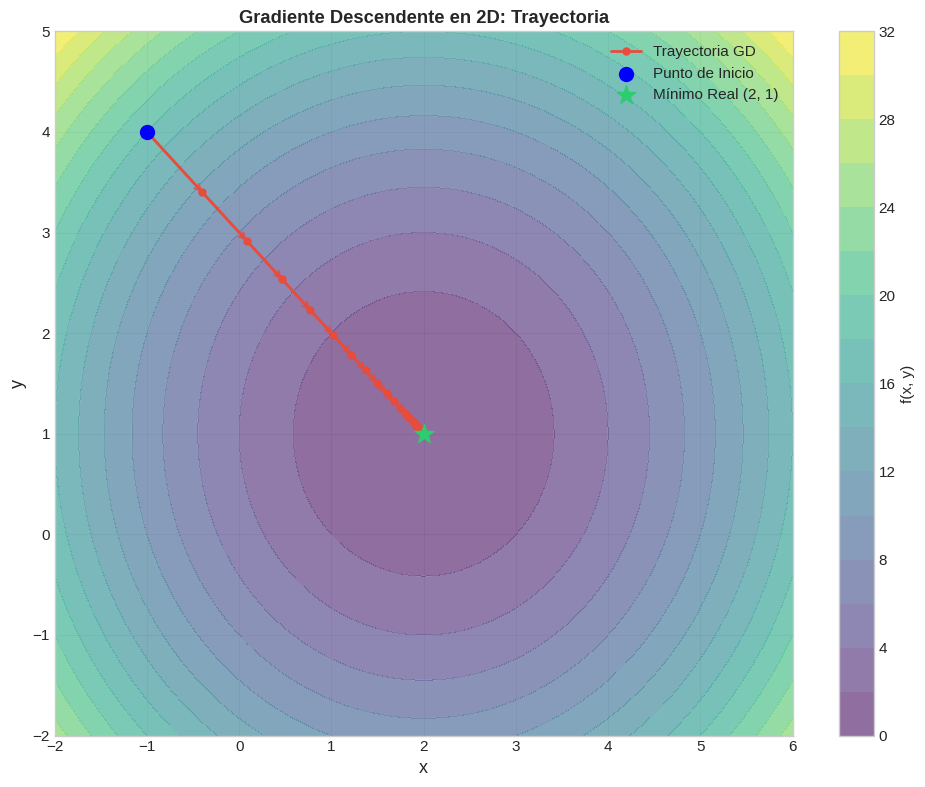

In [ ]:
# ============================================================
# TU CODIGO AQUI: Visualizacion del gradiente descendente 2D
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

# 1. Contornos de la funcion f(x, y)
# x2, y2, Z2 ya están definidos en una celda anterior
contour = ax.contourf(X2, Y2, Z2, levels=20, cmap='viridis', alpha=0.6)
ax.contour(X2, Y2, Z2, levels=20, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=ax, label='f(x, y)')

# 2. Trayectoria del gradiente descendente
hx = resultado_2d['historial_x']
hy = resultado_2d['historial_y']
ax.plot(hx, hy, 'o-', color='#e74c3c', markersize=5, linewidth=2, label='Trayectoria GD')

for i in range(min(10, len(hx) - 1)):
    ax.annotate('', xy=(hx[i+1], hy[i+1]), xytext=(hx[i], hy[i]),
                arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5, alpha=0.8, shrinkA=0, shrinkB=0))

# 3. Punto de inicio marcado
ax.scatter(hx[0], hy[0], color='blue', s=100, marker='o', zorder=5, label='Punto de Inicio')

# 4. El minimo real marcado con una estrella
ax.scatter([2], [1], color='#2ecc71', s=200, marker='*', zorder=6, label='Mínimo Real (2, 1)')

ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title('Gradiente Descendente en 2D: Trayectoria', fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_2d_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# EXTRA: Prueba con diferentes puntos iniciales en 2D
# ============================================================

# Prueba al menos 3 puntos iniciales diferentes y compara los resultados
puntos_iniciales = [
    (-1.0, 4.0),
    (5.0, -1.0),
    (0.0, 0.0),
]

In [ ]:
puntos_iniciales.extend(
    np.random.uniform(-15, 15, size=(2)) for _ in range(7)
)

In [ ]:
for x_inicial, y_inicial in puntos_iniciales:
  print(f"Punto inicial: ({x_inicial}, {y_inicial})")

Punto inicial: (-1.0, 4.0)
Punto inicial: (5.0, -1.0)
Punto inicial: (0.0, 0.0)
Punto inicial: (-3.7637964345791257, 13.521429192297486)
Punto inicial: (6.959818254342153, 2.959754525911098)
Punto inicial: (-10.319440786726904, -10.32016438991392)
Punto inicial: (-13.257491634954016, 10.985284373248057)
Punto inicial: (3.0334503522962635, 6.242177333881365)
Punto inicial: (-14.382465171125926, 14.09729556485983)
Punto inicial: (9.973279224012654, -8.629826679651716)


In [ ]:
resultados_2d = [
    gradiente_descendente_2d(
        x_inicial=x_inicial,
        y_inicial=y_inicial,
        learning_rate=0.1,
        max_iter=100
    )
    for x_inicial, y_inicial in puntos_iniciales
]

In [ ]:
print("EXPERIMENTOS CON DIFERENTES LEARNING RATES")
print("=" * 80)
print(f"{'LR':>8} {'x_final':>12} {'y_final':>12} {'f(x)_final':>12} {'Iteraciones':>12} {'Convergi\u00f3':>12}")
print("-" * 60)

for res in resultados_2d:
  print(f"{'0.1':>8} {res['x_final']:>12.6f} {res['y_final']:>12.6f} {res['f_final']:>12.6f} {res['iteraciones']:>12} {str(res['convergido']):>12}")

EXPERIMENTOS CON DIFERENTES LEARNING RATES
      LR      x_final      y_final   f(x)_final  Iteraciones    Convergió
------------------------------------------------------------
     0.1     2.000000     1.000000     0.000000           73         True
     0.1     2.000000     1.000000     0.000000           72         True
     0.1     2.000000     1.000000     0.000000           70         True
     0.1     2.000000     1.000000     0.000000           78         True
     0.1     2.000000     1.000000     0.000000           74         True
     0.1     2.000000     1.000000     0.000000           79         True
     0.1     2.000000     1.000000     0.000000           80         True
     0.1     2.000000     1.000000     0.000000           74         True
     0.1     2.000000     1.000000     0.000000           80         True
     0.1     2.000000     1.000000     0.000000           78         True


# Parte 4: Análizis y Generación de CSV

## Ejercicio 4.1:

In [ ]:
dataset = []

In [ ]:
lr_1d = [
    0.001,
    0.01,
    0.1,
    0.5,
    0.9,
    1.0,
    1.5
]

x_0_1d = [
    -2.0
]

lr_2d = [
    0.001,
    0.01,
    0.1,
    0.5
]

x_0_2d = [
    (-1.0, 4.0),
    (5.0, -1),
    (0.0, 0.0)
]

In [ ]:
for lr in lr_1d:
  for x_0 in x_0_1d:
    resultado_1d = gradiente_descendente_1d(
      x_inicial=x_0,
      learning_rate=lr,
      max_iter=200
    )

    dataset.append(
        {
            "learning_rate": lr,
            "dimension": "1D",
            "x_inicial": x_0,
            "y_inicial": np.nan,
            "x_final": resultado_1d['x_final'],
            "y_final": np.nan,
            "valor_minimo": resultado_1d['f_final'],
            "iteraciones": resultado_1d['iteraciones'],
            "convergido": resultado_1d['convergido']
        }
    )

In [ ]:
for lr in lr_2d:
  for x_0, y_0 in x_0_2d:
    resultado_2d = gradiente_descendente_2d(
      x_inicial=x_0,
      y_inicial=y_0,
      learning_rate=lr,
      max_iter=100
    )

    dataset.append(
      {
          "learning_rate": lr,
          "dimension": "2D",
          "x_inicial": x_0,
          "y_inicial": y_0,
          "x_final": resultado_2d['x_final'],
          "y_final": resultado_2d['y_final'],
          "valor_minimo": resultado_2d['f_final'],
          "iteraciones": resultado_2d['iteraciones'],
          "convergido": resultado_2d['convergido']
      }
    )

In [ ]:
df_experimentos = pd.DataFrame(dataset)
df_experimentos.to_csv('experimentos_gd.csv', index=False)

In [ ]:
print("CONTENIDO DEL CSV DE EXPERIMENTOS")
print("=" * 80)

df_experimentos = pd.read_csv('experimentos_gd.csv')
print(df_experimentos.to_string(index=False))
print(f"\nTotal de experimentos: {len(df_experimentos)}")

CONTENIDO DEL CSV DE EXPERIMENTOS
 learning_rate dimension  x_inicial  y_inicial       x_final   y_final  valor_minimo  iteraciones  convergido
         0.001        1D       -2.0        NaN -3.502581e-01       NaN  1.622423e+01          200       False
         0.010        1D       -2.0        NaN  2.912060e+00       NaN  5.007733e+00          200       False
         0.100        1D       -2.0        NaN  2.999996e+00       NaN  5.000000e+00           63        True
         0.500        1D       -2.0        NaN  3.000000e+00       NaN  5.000000e+00            2        True
         0.900        1D       -2.0        NaN  3.000000e+00       NaN  5.000000e+00           73        True
         1.000        1D       -2.0        NaN -2.000000e+00       NaN  3.000000e+01          200       False
         1.500        1D       -2.0        NaN -8.034690e+60       NaN 6.455625e+121          200       False
         0.001        2D       -1.0        4.0 -4.557004e-01  3.455700  1.206093e+01  

## Ejercicio 4.2:
**Responde las siguientes preguntas:**

1. **¿Cuál es el rango de learning rates que funciona bien para estas funciones?**
   - *Tal parece que los mejores learning rates están dados por: $α∈[0.1,1)$, ya que learning rates menores que 0.1 dan como resultado una convergencia excesivamente lenta, mientras que un $α$ mayor o igual a 1 no logra converger de forma adecuada.*

2. **¿El punto inicial afecta si el algoritmo converge? ¿Afecta cuántas iteraciones necesita?**
   - *Para funciones convexas como estas, el punto inicial no afecta si el algoritmo converge, siempre lo hará independientemente de dónde empieces. Lo que sí afecta es cuántas iteraciones necesita: un punto más alejado del mínimo requiere más pasos. Esto cambia drásticamente en funciones no convexas, donde el punto inicial determina a qué mínimo local llega el algoritmo, o incluso si converge.*

3. **¿Qué pasaría si la función tuviera múltiples mínimos locales? (piensa en una función como `sin(x) + x²/10`)**
   - *El gradiente descendiente se encargaría de llevarlo al mínimo que apunté y puede no ser el mínimo global. Aquí depende mucho del punto inicial y de la experimentación para poder obtener un mínimo que realmente garantice que sea el mínimo más eficiente.*

4. **Conecta con ML: Cuando entrenas un modelo, los pesos del modelo son como `x` e `y`, y la función de costo es como `f(x,y)`. ¿Por qué es importante elegir bien el learning rate al entrenar?**
   - *Porque si se desea minimizar el costo, lo más importante es que se llegue a ese mínimo de la forma más óptima y rápida posible para no gastar muchos recursos en muchas iteraciones, y además el learning rate es crítico para que converja el modelo.*

5. **¿Qué ventaja tiene usar el gradiente (pendiente) en lugar de simplemente probar valores al azar?**
   - *Si probamos valores al azar, estaremos sujetos al azar y a la posibilidad de que jamás encontremos un valor adecuado para el mínimo. Con el gradiente descendente tenemos una garantía de que se está haciendo, incluso si no converge el algoritmo; se puede entender la mecánica del mismo y corregirlo con cierta facilidad. Es el equivalente a ocupar Bogo Sort en un array de miles de datos de forma profesional.*

# BONUS

In [ ]:
# ================================================================
# DATOS PARA SGD
# ================================================================

np.random.seed(42)

# Generar datos: y = 3x + 7 + ruido
n_datos = 200
X_sgd = np.random.uniform(0, 10, n_datos)
y_sgd = 3 * X_sgd + 7 + np.random.normal(0, 2, n_datos)

print(f"Datos generados: {n_datos} muestras")
print(f"Relaci\u00f3n real: y = 3x + 7 + ruido")
print(f"\nTu objetivo: encontrar w \u2248 3 y b \u2248 7 usando SGD")

Datos generados: 200 muestras
Relación real: y = 3x + 7 + ruido

Tu objetivo: encontrar w ≈ 3 y b ≈ 7 usando SGD


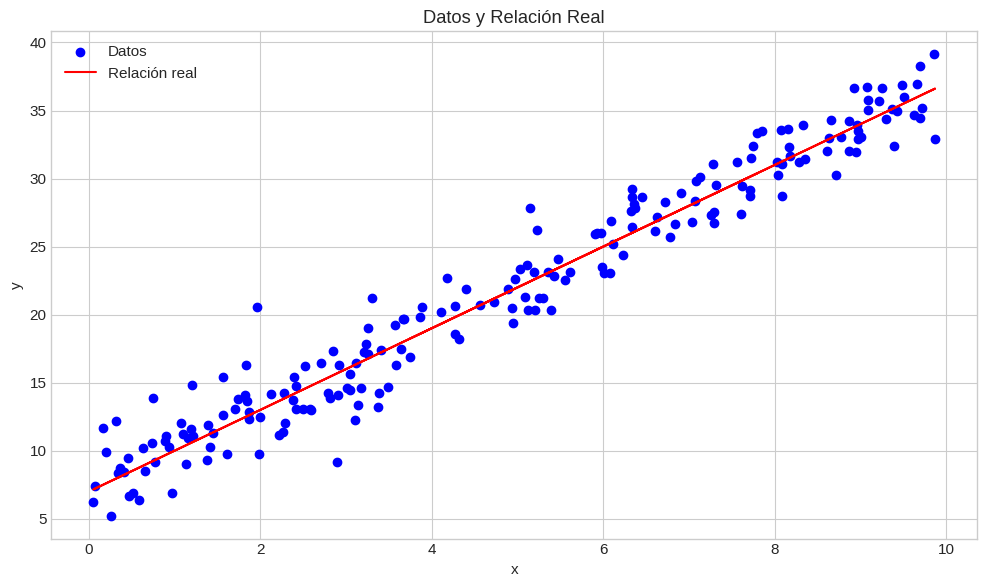

In [ ]:
plt.scatter(X_sgd, y_sgd, color='blue', label='Datos')
plt.plot(X_sgd, 3 * X_sgd + 7, color='red', label='Relación real')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Datos y Relación Real')
plt.tight_layout()
plt.show()

In [ ]:
def sgd_regresion_lineal(X, y, learning_rate=0.01, epochs=50, batch_size=32):
    """
    Implementa SGD con mini-batches para regresion lineal y = wx + b

    Parametros:
    -----------
    X : array - Datos de entrada
    y : array - Valores objetivo
    learning_rate : float
    epochs : int - Numero de pasadas completas por los datos
    batch_size : int - Tamano del mini-batch

    Retorna:
    --------
    dict con:
        'w_final': float - Pendiente aprendida
        'b_final': float - Intercepto aprendido
        'historial_loss': list - MSE por epoch
        'historial_w': list - w por epoch
        'historial_b': list - b por epoch
    """

    # ============================================================
    # TU CODIGO AQUI
    # ============================================================

    # 1. Inicializa w = 0, b = 0
    # 2. Para cada epoch:
    #    a. Mezcla los indices aleatoriamente
    #    b. Para cada mini-batch:
    #       - Selecciona batch_size muestras
    #       - Calcula prediccion: y_pred = w * X_batch + b
    #       - Calcula error: error = y_batch - y_pred
    #       - Calcula gradientes:
    #           dw = -2/batch_size * sum(error * X_batch)
    #           db = -2/batch_size * sum(error)
    #       - Actualiza: w = w - lr * dw, b = b - lr * db
    #    c. Calcula MSE del epoch completo y guarda en historial

    w = 0
    b = 0

    n_muestras = len(X)
    indices = np.arange(n_muestras)
    historial_loss = []
    historial_w = [0]
    historial_b = [0]

    for _ in range(epochs):
        np.random.shuffle(indices)

        for i in range(0, n_muestras, batch_size):
          batch_indices = indices[i:i+batch_size]

          X_batch = X[batch_indices]
          y_batch = y[batch_indices]

          y_pred = w * X_batch + b
          error = y_batch - y_pred

          dw = -2 * np.mean(error * X_batch)
          db = -2 * np.mean(error)

          w -= learning_rate * dw
          b -= learning_rate * db

        y_pred = w * X + b
        mse = np.mean((y - y_pred)**2)

        historial_loss.append(mse)
        historial_w.append(w)
        historial_b.append(b)

    return {
        'w_final': w,
        'b_final': b,
        'historial_loss': historial_loss,
        'historial_w': historial_w,
        'historial_b': historial_b
    }

In [ ]:
resultado_sgd = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=32)

In [ ]:
print("Ecuación Aprendida por el modelo:")
print(f"y = {resultado_sgd['w_final']}x + {resultado_sgd['b_final']}")

Ecuación Aprendida por el modelo:
y = 3.2470079270289305x + 6.169224718325242


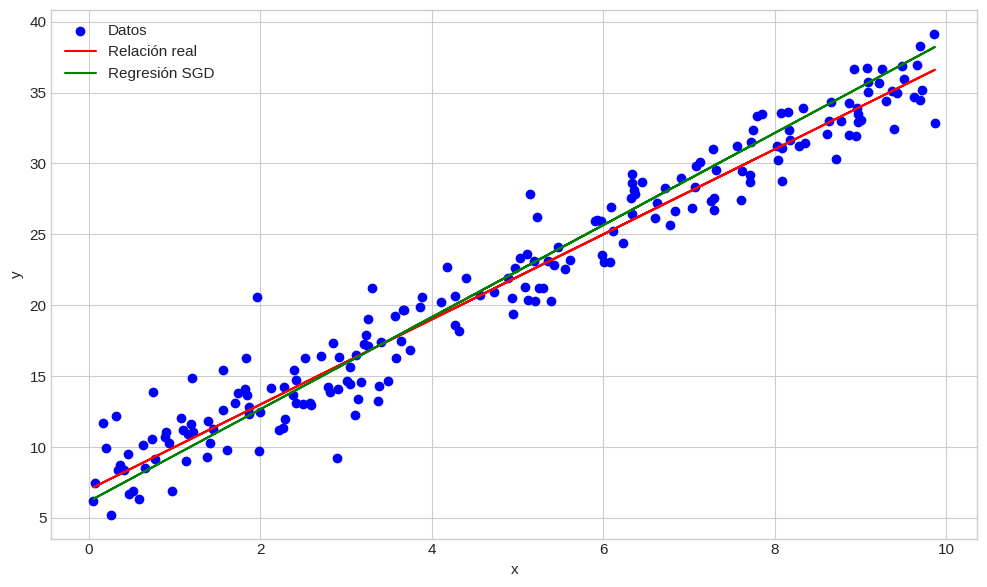

In [ ]:
plt.scatter(X_sgd, y_sgd, color='blue', label='Datos')
plt.plot(X_sgd, 3 * X_sgd + 7, color='red', label='Relación real')
plt.plot(X_sgd, resultado_sgd['w_final'] * X_sgd + resultado_sgd['b_final'], color='green', label='Regresión SGD')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

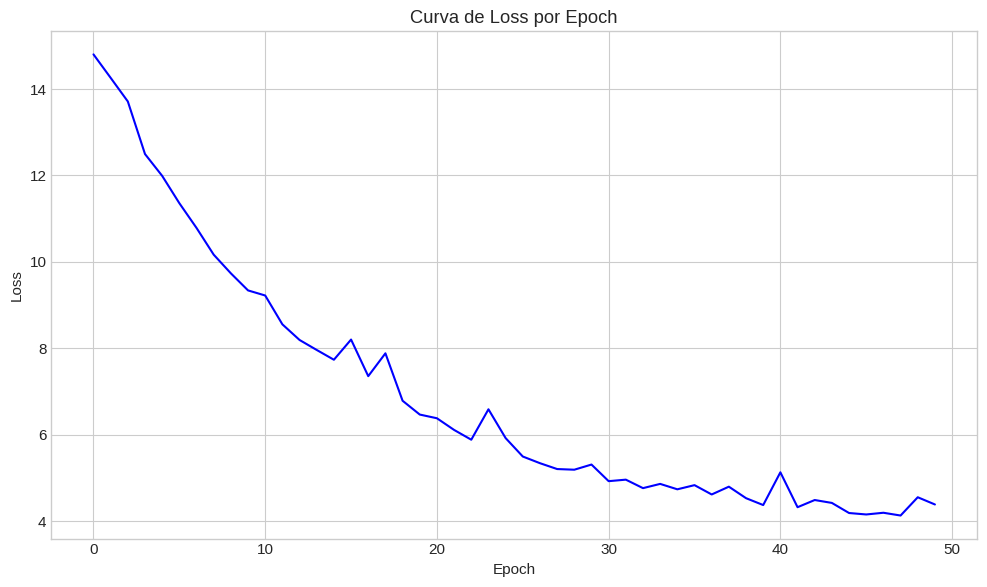

In [ ]:
plt.plot(resultado_sgd["historial_loss"], color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curva de Loss por Epoch')
plt.tight_layout()
plt.show()

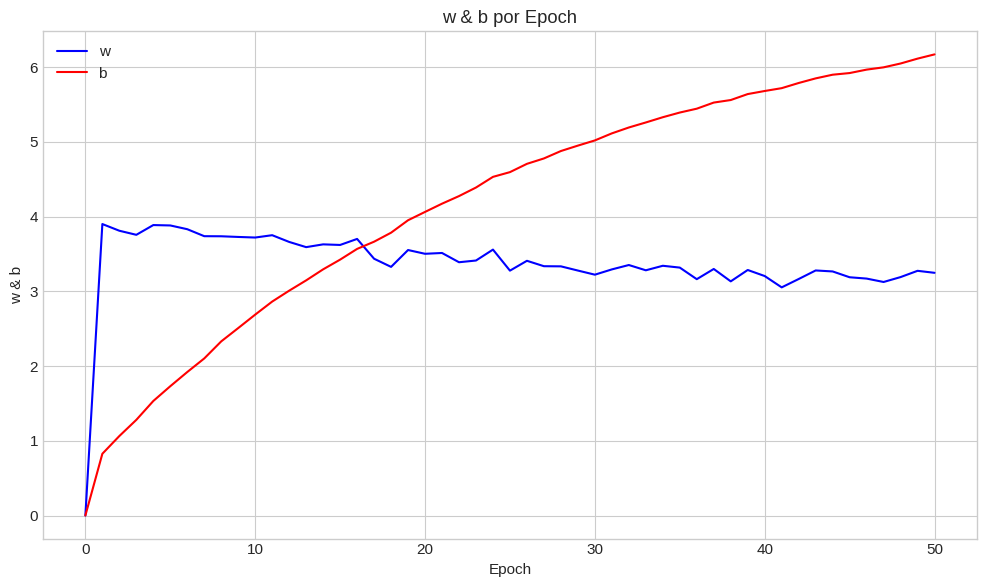

In [ ]:
plt.plot(resultado_sgd["historial_w"], color='blue')
plt.plot(resultado_sgd["historial_b"], color='red')
plt.xlabel('Epoch')
plt.ylabel('w & b')
plt.title('w & b por Epoch')
plt.legend(['w', 'b'], loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
batch_sizes = [1, 8, 32, 64, n_datos]

In [ ]:
resultados_sgd = []

In [ ]:
for batch_size in batch_sizes:
  resultado_sgd = sgd_regresion_lineal(
      X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=batch_size
  )

  resultados_sgd.append(resultado_sgd)

In [ ]:
for resultado in resultados_sgd:
  print("="*80)
  print("Batch Size:")
  print(f"  {batch_sizes[resultados_sgd.index(resultado)]}")
  print("Ecuación Aprendida por el modelo:")
  print(f"  y = {resultado['w_final']}x + {resultado['b_final']}")
  print("Loss final del modelo:")
  print(f"  {resultado['historial_loss'][-1]}")
  print("="*80)

Batch Size:
  1
Ecuación Aprendida por el modelo:
  y = 2.8107678335324477x + 7.3223926119384055
Loss final del modelo:
  4.5265888897104425
Batch Size:
  8
Ecuación Aprendida por el modelo:
  y = 2.9314517463096528x + 7.191345292622655
Loss final del modelo:
  3.8353181924107753
Batch Size:
  32
Ecuación Aprendida por el modelo:
  y = 3.0669707359804463x + 6.200141875529564
Loss final del modelo:
  4.167082133930745
Batch Size:
  64
Ecuación Aprendida por el modelo:
  y = 3.2435663613367582x + 4.902365333358215
Loss final del modelo:
  5.426585717341404
Batch Size:
  200
Ecuación Aprendida por el modelo:
  y = 3.7556055337926444x + 2.1409500263723764
Loss final del modelo:
  10.66847492369057


In [ ]:
colors = ['green', 'purple', 'orange', 'cyan', 'magenta']

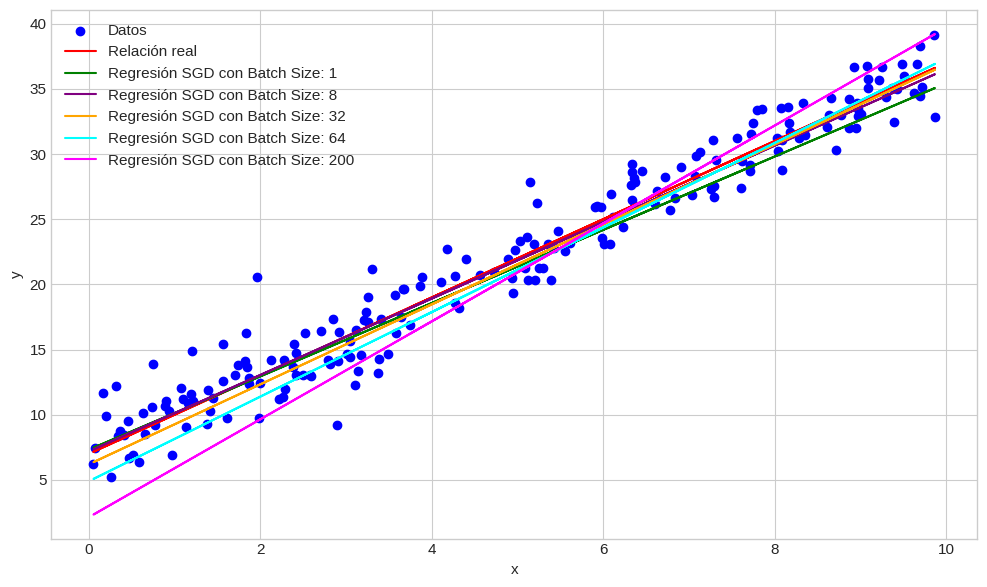

In [ ]:
plt.scatter(X_sgd, y_sgd, color='blue', label='Datos')
plt.plot(X_sgd, 3 * X_sgd + 7, color='red', label='Relación real')

for resultado in resultados_sgd:
  plt.plot(X_sgd, resultado['w_final'] * X_sgd + resultado['b_final'],
           color=colors[resultados_sgd.index(resultado)],
           label=f'Regresión SGD con Batch Size: {batch_sizes[resultados_sgd.index(resultado)]}')
  plt.xlabel('x')
  plt.ylabel('y')
  plt.legend()
  plt.tight_layout()

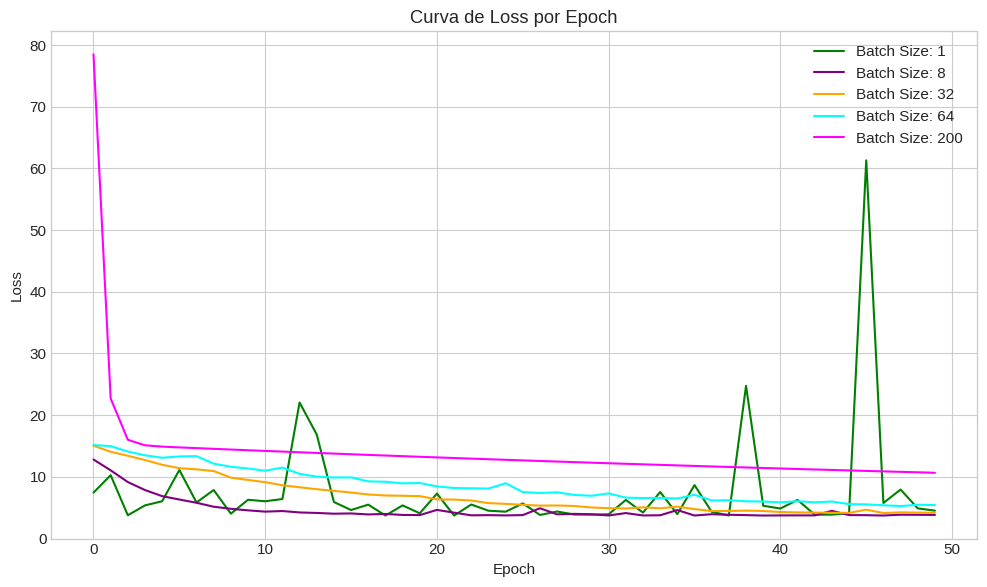

In [ ]:
for resultado in resultados_sgd:
  plt.plot(resultado["historial_loss"],
           color=colors[resultados_sgd.index(resultado)],
           label=f'Batch Size: {batch_sizes[resultados_sgd.index(resultado)]}'
           )
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Curva de Loss por Epoch')
  plt.tight_layout()

plt.legend()
plt.show()

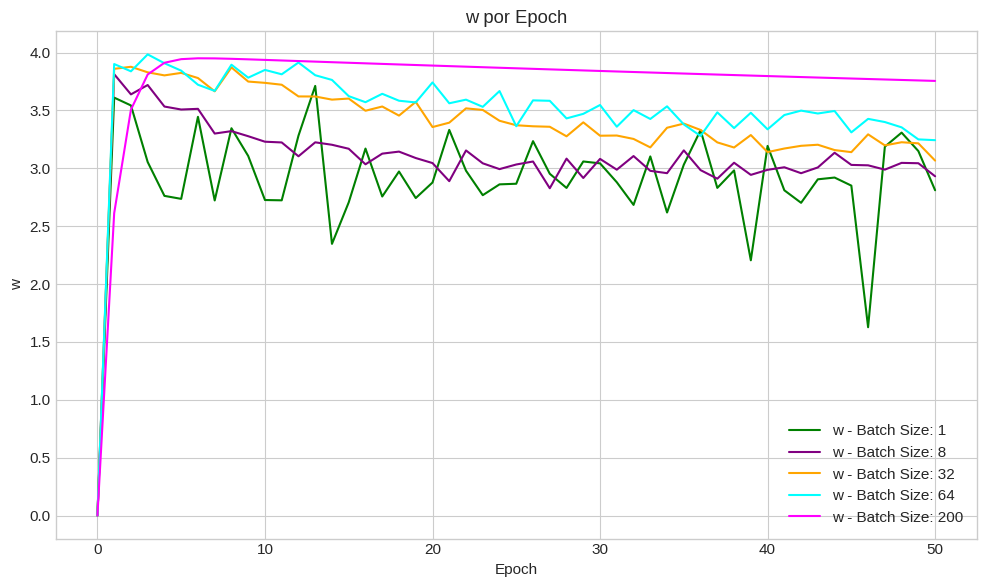

In [ ]:
for resultado in resultados_sgd:
  plt.plot(resultado['historial_w'], color=colors[resultados_sgd.index(resultado)],
           label=f'w - Batch Size: {batch_sizes[resultados_sgd.index(resultado)]}')
  plt.xlabel('Epoch')
  plt.ylabel('w')
  plt.title('w por Epoch')
  plt.tight_layout()

plt.legend()
plt.show()

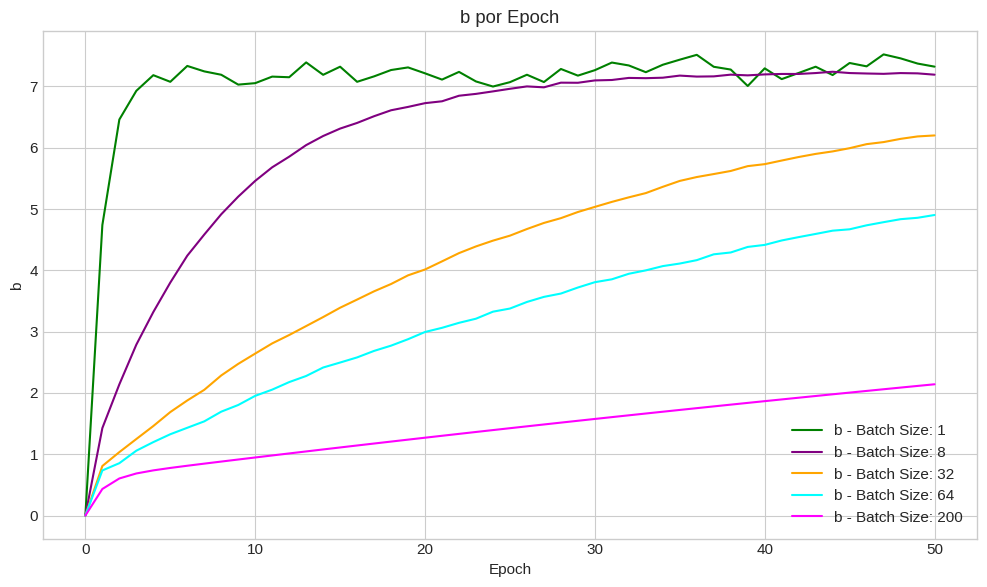

In [ ]:
for resultado in resultados_sgd:
  plt.plot(resultado['historial_b'], color=colors[resultados_sgd.index(resultado)],
           label=f'b - Batch Size: {batch_sizes[resultados_sgd.index(resultado)]}')
  plt.xlabel('Epoch')
  plt.ylabel('b')
  plt.title('b por Epoch')
  plt.tight_layout()

plt.legend()
plt.show()

**Preguntas Bonus:**

1. **¿Qué diferencia notas entre GD puro (batch_size=n) y SGD (batch_size=1)?**
   - *GD puro no logra converger tan rápido como se esperaba y SGD es más inestable, pero en general logra una convergencia bastante rápida.*

2. **¿Cúal batch_size te dio los mejores resultados? ¿Por qué?**
   - *Batch size de 1, ya que, aunque era bastante ruidoso, sí se mantiene en valores cercanos a los esperados, además de que tiene la menor pérdida posible; también los batch sizes de 8 y 32 fueron bastante buenos.*

3. **¿Por qué la curva de loss de SGD es más ruidosa que la de GD?**
   - *Porque en SGD puro, todo depende del dato seleccionado y, por ende, se tiene que ir actualizando por cada uno de los datos que encuentre, mientras que en GD, se va actualizando según el gradiente global, el cual es más estable por cada iteración.*